# 07 · Customer Churn Prediction con Spark MLlib

**Objetivo:** construir un pipeline de clasificación distribuido con Spark MLlib que estime la probabilidad de que un cliente de telecomunicaciones abandone el servicio (*churn*).

**Pregunta de negocio:** ¿qué clientes tienen mayor probabilidad de abandonar el servicio y qué factores se asocian a ese abandono?

**Dataset:** Telco Customer Churn (IBM) · 7.043 clientes · 21 columnas · CSV de ~1 MB.

**Stack:** PySpark 4 (Spark SQL + MLlib) · scikit-learn (comparativa) · pandas · matplotlib.

### Resultados principales

| | |
|---|---|
| Modelo seleccionado | Regresión logística |
| AUC-ROC / AUC-PR (test) | 0,861 / 0,664 |
| Umbral de decisión | 0,4 |
| Recall de churn con ese umbral | 72 % (235 de 328 churners del conjunto de test) |
| Factores principales | Antigüedad, tipo de contrato, fibra óptica, método de pago |

### Contenido

| # | Sección |
|---|---|
| 1 | Setup |
| 2 | Carga de datos |
| 3 | Exploración |
| 4 | Preparación de datos para el modelo |
| 5 | Selección de features |
| 6 | Train / test split |
| 7 | Pipeline de preprocesado |
| 8 | Entrenamiento de modelos |
| 9 | Evaluación |
| 10 | Umbral de decisión |
| 11 | Interpretabilidad |
| 12 | Predicciones y resultados |
| 13 | Comparación con scikit-learn |
| 14 | Conclusiones generales |

## 1. Setup

Configuración de la sesión de Spark y rutas del proyecto.

In [1]:
from pathlib import Path
import sys
import time
import json


PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "common").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("No se encontró la carpeta 'common'.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from common.spark_session import create_spark_session
from pyspark.sql import functions as F

import importlib, common.profiling
importlib.reload(common.profiling)
from common.profiling import duplicate_count, cardinality_profile, frequency_profile, missing_values_profile

from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
)

spark = create_spark_session(app_name="07-churn-telco-prediction")
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/30 13:23:04 WARN Utils: Your hostname, MacBook-Air-de-Gloria.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.20 instead (on interface en0)
26/09/30 13:23:04 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/30 13:23:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/30 13:23:06 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/09/30 13:23:06 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/09/30 13:23:06 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


In [2]:
DATA_PATH = PROJECT_ROOT / "datasets" / "05-telco-customer-churn" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
PROJECT_DIR = PROJECT_ROOT / "projects" / "07-churn-telco-prediction"
OUTPUT_DIR = PROJECT_DIR / "output"

# Semilla para que split y modelos sean reproducibles
SEED = 42

print(f"Dataset encontrado: {DATA_PATH.exists()}")

Dataset encontrado: True


## 2. Carga de datos

El dataset es un CSV de ~1 MB con **un cliente por fila**: datos demográficos, servicios contratados, tipo de contrato, facturación y si el cliente abandonó la compañía (**churn**).

Se carga con **inferSchema=True** para la exploración inicial. Un CSV no guarda tipos, así que Spark los deduce recorriendo los datos; en producción conviene definir el esquema de forma explícita. Como se verá en el apartado 3.1.2, la inferencia no siempre produce el tipo esperado.

In [3]:
raw_df = spark.read.csv(str(DATA_PATH), header=True, inferSchema=True)

raw_df.printSchema()

raw_df.show(5, truncate=False)

root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: string (nullable = true)
 |-- Churn: string (nullable = true)

+----------+------+-------------+-------+----------+------+------------+---------

Los nombres de columna originales mezclan estilos (**customerID**, **MonthlyCharges**, **StreamingTV**). Se normalizan a **snake_case** justo después de la lectura, de modo que todo el notebook trabaja con una única convención.

In [4]:
import re

def to_snake_case(name):
    name = re.sub(r"([a-z0-9])([A-Z])", r"\1_\2", name)   # MonthlyCharges → Monthly_Charges
    name = re.sub(r"([A-Z]+)([A-Z][a-z])", r"\1_\2", name) # siglas: XMLFile → XML_File
    return name.lower()

raw_df = raw_df.toDF(*[to_snake_case(c) for c in raw_df.columns])
print(raw_df.columns)

['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn']


In [5]:
# ✅ Comprobación
assert raw_df.count() == 7043, "El dataset debería tener 7.043 clientes"
assert len(raw_df.columns) == 21, "El dataset debería tener 21 columnas"
print("✅ Datos cargados correctamente")

✅ Datos cargados correctamente


## 3. Exploración

La exploración se divide en dos partes:

- **Perfil y calidad de los datos (3.1):** cada columna por separado: duplicados, valores ausentes, cardinalidad y distribución.
- **Relación con la variable objetivo (3.2–3.4):** balance de clases y tasa de churn por variable.

Las correcciones se aplican en el momento en que se detecta cada problema, en celdas marcadas con **🧹 LIMPIEZA**. Todas parten de **raw_df**, que no se modifica, y construyen **df_clean**.

### 3.1 Perfil y calidad de los datos

Resumen estadístico inicial y clasificación preliminar de las columnas según su tipo y su significado.

In [6]:
raw_df.summary().show()

26/09/30 13:23:12 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-----------+------+------------------+-------+----------+------------------+-------------+--------------+----------------+---------------+-------------+-----------------+------------+------------+----------------+--------------+-----------------+--------------------+------------------+------------------+-----+
|summary|customer_id|gender|    senior_citizen|partner|dependents|            tenure|phone_service|multiple_lines|internet_service|online_security|online_backup|device_protection|tech_support|streaming_tv|streaming_movies|      contract|paperless_billing|      payment_method|   monthly_charges|     total_charges|churn|
+-------+-----------+------+------------------+-------+----------+------------------+-------------+--------------+----------------+---------------+-------------+-----------------+------------+------------+----------------+--------------+-----------------+--------------------+------------------+------------------+-----+
|  count|       7043|  7043|         

In [7]:
# Clasificación preliminar (antes de la limpieza)
id_col = 'customer_id'
label = 'churn'

cat_multi = ['internet_service', 'contract', 'payment_method',
             'multiple_lines', 'online_security', 'online_backup', 'device_protection',
             'tech_support', 'streaming_tv', 'streaming_movies']

cat_binary = ['gender', 'partner', 'dependents', 'phone_service', 'paperless_billing']

num_binary = ['senior_citizen']
num_cont = ['tenure', 'monthly_charges', 'total_charges']

#### 3.1.1 Duplicados

In [8]:
# Filas completamente duplicadas y unicidad del identificador
n_rows = raw_df.count()
unique_rows = raw_df.distinct().count()
unique_ids = raw_df.select("customer_id").distinct().count()

print(f"Filas: {n_rows:,} · Filas distintas: {unique_rows:,} · customer_id distintos: {unique_ids:,}")

Filas: 7,043 · Filas distintas: 7,043 · customer_id distintos: 7,043


In [9]:
# Perfiles idénticos excluyendo el identificador
duplicate_count(raw_df, exclude_columns=["customer_id"]).show()

cols = [c for c in raw_df.columns if c != "customer_id"]

duplicate_groups = (
    raw_df
    .groupBy(*cols)
    .count()
    .filter(F.col("count") > 1)
    .orderBy(F.desc("count"))
)

duplicate_groups.show(10, truncate=False)

+----------------+--------------+
|duplicate_groups|duplicate_rows|
+----------------+--------------+
|              20|            22|
+----------------+--------------+

+------+--------------+-------+----------+------+-------------+--------------+----------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+-----------------+----------------+---------------+-------------+-----+-----+
|gender|senior_citizen|partner|dependents|tenure|phone_service|multiple_lines|internet_service|online_security    |online_backup      |device_protection  |tech_support       |streaming_tv       |streaming_movies   |contract      |paperless_billing|payment_method  |monthly_charges|total_charges|churn|count|
+------+--------------+-------+----------+------+-------------+--------------+----------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------

<div style="background-color: #162B36; color: #E6EDF3; padding: 20px; border-radius: 12px; border-left: 5px solid #38BDF8;">

### 🔁 Duplicados

No hay registros duplicados; customer_id es único (7.043 valores distintos para 7.043 filas). Sin embargo, excluyendo el identificador, 42 clientes comparten perfil con al menos otro cliente (20 patrones distintos). Se trata de coincidencias legítimas: las variables son categóricas con pocos valores y es esperable que clientes con perfiles sencillos coincidan en todas ellas. **Decisión:** se conservan todas las filas.

</div>

#### 3.1.2 Nulos y valores vacíos

In [10]:
missing_markers = {
    "na_count": "NA",
    "unknown_count": "Unknown",
}

# Nulos, NaN, valores en blanco y marcadores de texto por columna
missing_values_profile(raw_df, string_markers=missing_markers, output="percentage").show()

+-------------+----------+---------+-----------+--------+-------------+-------------+
|  column_name|null_count|nan_count|blank_count|na_count|unknown_count|missing_total|
+-------------+----------+---------+-----------+--------+-------------+-------------+
|total_charges|       0.0|      0.0|       0.16|     0.0|          0.0|         0.16|
+-------------+----------+---------+-----------+--------+-------------+-------------+



In [11]:
(
    raw_df
    .filter(F.trim(F.col("total_charges")) == "")
    .select("customer_id", "tenure", "monthly_charges", "total_charges", "churn")
    .show()
)

+-----------+------+---------------+-------------+-----+
|customer_id|tenure|monthly_charges|total_charges|churn|
+-----------+------+---------------+-------------+-----+
| 4472-LVYGI|     0|          52.55|             |   No|
| 3115-CZMZD|     0|          20.25|             |   No|
| 5709-LVOEQ|     0|          80.85|             |   No|
| 4367-NUYAO|     0|          25.75|             |   No|
| 1371-DWPAZ|     0|          56.05|             |   No|
| 7644-OMVMY|     0|          19.85|             |   No|
| 3213-VVOLG|     0|          25.35|             |   No|
| 2520-SGTTA|     0|           20.0|             |   No|
| 2923-ARZLG|     0|           19.7|             |   No|
| 4075-WKNIU|     0|          73.35|             |   No|
| 2775-SEFEE|     0|           61.9|             |   No|
+-----------+------+---------------+-------------+-----+



<div style="background-color: #162B36; color: #E6EDF3; padding: 20px; border-radius: 12px; border-left: 5px solid #38BDF8;">

### 🕳️ Valores vacíos en total_charges

total_charges contiene 11 valores en blanco (0,16 %), lo que hizo que Spark la infiriera como string. Los 11 corresponden a clientes con tenure = 0: acaban de darse de alta y todavía no se les ha facturado, así que el dato es coherente, no un error.
   

**Decisión:** se eliminan del entrenamiento, porque su etiqueta no es fiable. Con 0 meses de permanencia no han tenido oportunidad de abandonar, y los 11 figuran como churn = No. El impacto en el volumen es despreciable (7.043 → 7.032 clientes).

</div>

In [12]:
# 🧹 LIMPIEZA — total_charges a double y eliminación de los 11 clientes sin facturación
df_clean = (
    raw_df
    .withColumn("total_charges", F.col("total_charges").try_cast("double"))
    .dropna(subset=["total_charges"])
)

removed = raw_df.count() - df_clean.count()
assert removed == 11, f"Se esperaban 11 filas eliminadas y se han eliminado {removed}"

print(f"✅ Eliminadas {removed} filas · {df_clean.count():,} clientes")

✅ Eliminadas 11 filas · 7,032 clientes


#### 3.1.3 Cardinalidad y frecuencias (categóricas)

In [13]:
cardinality_profile(df_clean, columns=cat_binary + cat_multi).show()

+-----------------+---------------+---------------+
|      column_name|distinct_values|cardinality_pct|
+-----------------+---------------+---------------+
|   payment_method|              4|           0.06|
| internet_service|              3|           0.04|
|         contract|              3|           0.04|
|   multiple_lines|              3|           0.04|
|  online_security|              3|           0.04|
|    online_backup|              3|           0.04|
|device_protection|              3|           0.04|
|     tech_support|              3|           0.04|
|     streaming_tv|              3|           0.04|
| streaming_movies|              3|           0.04|
|           gender|              2|           0.03|
|          partner|              2|           0.03|
|       dependents|              2|           0.03|
|    phone_service|              2|           0.03|
|paperless_billing|              2|           0.03|
+-----------------+---------------+---------------+



In [14]:
for c in cat_binary + cat_multi:
    print(c)
    frequency_profile(df_clean, column=c, limit=5).show(truncate=False)

gender
+--------+-----+----------+
|category|count|percentage|
+--------+-----+----------+
|Male    |3549 |50.47     |
|Female  |3483 |49.53     |
+--------+-----+----------+

partner
+--------+-----+----------+
|category|count|percentage|
+--------+-----+----------+
|No      |3639 |51.75     |
|Yes     |3393 |48.25     |
+--------+-----+----------+

dependents
+--------+-----+----------+
|category|count|percentage|
+--------+-----+----------+
|No      |4933 |70.15     |
|Yes     |2099 |29.85     |
+--------+-----+----------+

phone_service
+--------+-----+----------+
|category|count|percentage|
+--------+-----+----------+
|Yes     |6352 |90.33     |
|No      |680  |9.67      |
+--------+-----+----------+

paperless_billing
+--------+-----+----------+
|category|count|percentage|
+--------+-----+----------+
|Yes     |4168 |59.27     |
|No      |2864 |40.73     |
+--------+-----+----------+

internet_service
+-----------+-----+----------+
|category   |count|percentage|
+-----------+-----

<div style="background-color: #162B36; color: #E6EDF3; padding: 20px; border-radius: 12px; border-left: 5px solid #38BDF8;">

### 🔁 Información redundante entre columnas

Las tablas de frecuencias muestran que algunas categorías se repiten con exactamente el mismo número de clientes en varias columnas:

| Categoría | Columnas donde aparece | Clientes | Coincide con |
|---|---|---:|---|
| No internet service | online_security, online_backup, device_protection, tech_support, streaming_tv, streaming_movies | 1.526 | internet_service = No |
| No phone service | multiple_lines | 682 | phone_service = No |

#### 🔎 Comprobación

No se trata solo de una coincidencia en los recuentos: son **los mismos registros**. No existe ningún cliente sin internet que tenga otro valor en esas columnas, ni ningún cliente sin teléfono con otro valor en multiple_lines.

#### ⚠️ Por qué es un problema

Esta tercera categoría no aporta información nueva: repite en siete columnas algo que ya recogen internet_service y phone_service. Mantenerla tendría dos efectos:

- El one-hot generaría variables perfectamente correlacionadas entre sí.
- En la regresión logística, el mismo efecto se repartiría entre varios coeficientes, lo que dificulta su interpretación.

#### ✅ Decisión

- En la limpieza se recodifican **No internet service** y **No phone service** como **No**.
- Las siete columnas pasan a ser **binarias (Yes / No)** sin pérdida de información: la ausencia del servicio sigue registrada en internet_service y phone_service.

</div>

In [15]:
# 🧹 LIMPIEZA — recodificación de categorías redundantes

INTERNET_SERVICE_COLS = [
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies",
]

# Comprobación sobre los datos originales: la tercera categoría
# coincide exactamente con la ausencia del servicio
for c in INTERNET_SERVICE_COLS:
    mismatches = raw_df.filter(
        (F.col("internet_service") == "No") != (F.col(c) == "No internet service")
    ).count()
    assert mismatches == 0, f"{c}: {mismatches} registros no coinciden con internet_service = No"

mismatches = raw_df.filter(
    (F.col("phone_service") == "No") != (F.col("multiple_lines") == "No phone service")
).count()
assert mismatches == 0, f"multiple_lines: {mismatches} registros no coinciden con phone_service = No"


# Recodificación: la tercera categoría pasa a "No"
for c in INTERNET_SERVICE_COLS:
    df_clean = df_clean.withColumn(
        c,
        F.when(F.col(c) == "No internet service", "No").otherwise(F.col(c))
    )

df_clean = df_clean.withColumn(
    "multiple_lines",
    F.when(F.col("multiple_lines") == "No phone service", "No").otherwise(F.col("multiple_lines"))
)


# Comprobación: las siete columnas quedan como binarias Yes/No
for c in INTERNET_SERVICE_COLS + ["multiple_lines"]:
    values = {r[c] for r in df_clean.select(c).distinct().collect()}
    assert values == {"Yes", "No"}, f"{c} tiene valores inesperados: {values}"

print("✅ Recodificación correcta: 7 columnas binarias Yes/No")

✅ Recodificación correcta: 7 columnas binarias Yes/No


In [16]:
# Cardinalidad tras la recodificación
cardinality_profile(df_clean, columns=cat_binary + cat_multi).show()

+-----------------+---------------+---------------+
|      column_name|distinct_values|cardinality_pct|
+-----------------+---------------+---------------+
|   payment_method|              4|           0.06|
| internet_service|              3|           0.04|
|         contract|              3|           0.04|
|           gender|              2|           0.03|
|          partner|              2|           0.03|
|       dependents|              2|           0.03|
|    phone_service|              2|           0.03|
|paperless_billing|              2|           0.03|
|   multiple_lines|              2|           0.03|
|  online_security|              2|           0.03|
|    online_backup|              2|           0.03|
|device_protection|              2|           0.03|
|     tech_support|              2|           0.03|
|     streaming_tv|              2|           0.03|
| streaming_movies|              2|           0.03|
+-----------------+---------------+---------------+



#### 3.1.4 Distribución (numéricas)

In [17]:
import importlib, common.profiling
importlib.reload(common.profiling)
from common.profiling import numeric_summary

numeric_summary(df_clean).show(truncate=False)

+-------+--------------+------+---------------+-------------+
|summary|senior_citizen|tenure|monthly_charges|total_charges|
+-------+--------------+------+---------------+-------------+
|count  |7032.0        |7032.0|7032.0         |7032.0       |
|mean   |0.16          |32.42 |64.8           |2283.3       |
|stddev |0.37          |24.55 |30.09          |2266.77      |
|min    |0.0           |1.0   |18.25          |18.8         |
|25%    |0.0           |9.0   |35.55          |401.1        |
|50%    |0.0           |29.0  |70.35          |1396.9       |
|75%    |0.0           |55.0  |89.85          |3791.6       |
|max    |1.0           |72.0  |118.75         |8684.8       |
+-------+--------------+------+---------------+-------------+



<div style="background-color: #162B36; color: #E6EDF3; padding: 20px; border-radius: 12px; border-left: 5px solid #38BDF8;">

### 📊 Distribución de variables numéricas

| Variable | Rango | Mediana | Media | Observación |
|---|---|---:|---:|---|
| tenure | 1 – 72 meses | 29 | 32,4 | Distribución amplia: el 25 % de los clientes lleva 9 meses o menos y otro 25 %, 55 meses o más |
| monthly_charges | 18,25 – 118,75 | 70,35 | 64,80 | Media inferior a la mediana: grupo de clientes con cuotas bajas (sin servicio de internet) |
| total_charges | 18,80 – 8.684,80 | 1.396,90 | 2.283,30 | Fuertemente asimétrica a la derecha: acumula la facturación de toda la relación con el cliente |
| senior_citizen | 0 / 1 | — | 0,16 | El 16 % de los clientes son personas mayores |

No se observan valores imposibles (negativos o fuera de rango). El mínimo de tenure es 1 porque los 11 clientes con tenure = 0 se eliminaron en el apartado 3.1.2.

**Redundancia:** total_charges es aproximadamente tenure × monthly_charges. Las tres variables están muy correlacionadas, lo que se tendrá en cuenta al interpretar los coeficientes del modelo (sección 11).

</div>

### 3.2 Balance de clases

La proporción de clientes que abandonan condiciona qué métricas de evaluación tienen sentido.

In [18]:
total = df_clean.count()

class_balance = (
    df_clean
    .groupBy("churn")
    .agg(F.count("*").alias("count"))
    .withColumn("pct", F.round(F.col("count") / F.lit(total) * 100, 2))
    .orderBy(F.desc("count"))
)

class_balance.show()

+-----+-----+-----+
|churn|count|  pct|
+-----+-----+-----+
|   No| 5163|73.42|
|  Yes| 1869|26.58|
+-----+-----+-----+



<div style="background-color: #162B36; color: #E6EDF3; padding: 20px; border-radius: 12px; border-left: 5px solid #38BDF8;">

### ⚖️ Balance de la variable objetivo

La variable objetivo presenta un **desbalanceo moderado**. La clase positiva (**churn = Yes**) representa el **26,58 %** de los clientes, frente al **73,42 %** de la clase negativa.

Por este motivo, la evaluación del modelo **no debe basarse únicamente en accuracy**, ya que un modelo que predijera siempre la clase mayoritaria alcanzaría aproximadamente un **73,42 % de accuracy** sin aportar capacidad predictiva real sobre los clientes que abandonan.

Para la evaluación se priorizarán especialmente:

- **Recall de la clase positiva (churn = Yes)**: proporción de clientes que realmente abandonan y que el modelo consigue detectar.
- **Precision**: proporción de clientes predichos como churn que realmente abandonan.
- **F1-score**: equilibrio entre precision y recall.
- **ROC-AUC** y **PR-AUC**, siendo esta última especialmente útil cuando existe desbalanceo entre clases.

En esta fase **no se aplicarán técnicas de oversampling o undersampling de forma automática**. Primero se entrenará un modelo baseline y se analizará su comportamiento sobre la clase positiva.

Si el modelo presenta un recall insuficiente para **churn = Yes**, se valorarán posteriormente estrategias como:

- ponderación de clases (**weightCol** en Spark MLlib);
- resampling;
- ajuste del threshold de decisión.

</div>

### 3.3 Tasa de churn por variable categórica

Para cada valor de una variable: número de clientes, clientes con churn y tasa de churn (%). La función **churn_rate_by** se reutiliza también en el apartado 3.4.

In [19]:
def churn_rate_by(df, col):
    """
    Tasa de churn para cada valor de una columna, ordenada de mayor a menor.
    """
    return (
        df
        .groupBy(col)
        .agg(
            F.count("*").alias("client_count"),
            F.sum(F.when(F.col("churn") == "Yes", 1).otherwise(0)).alias("churn_clients"),
            F.round(F.avg((F.col("churn") == "Yes").cast("int")) * 100, 2).alias("churn_rate"),
        )
        .orderBy(F.desc("churn_rate"))
    )


for col in ["contract", "internet_service", "payment_method", "tech_support"]:
    churn_rate_by(df_clean, col).show(truncate=False)

+--------------+------------+-------------+----------+
|contract      |client_count|churn_clients|churn_rate|
+--------------+------------+-------------+----------+
|Month-to-month|3875        |1655         |42.71     |
|One year      |1472        |166          |11.28     |
|Two year      |1685        |48           |2.85      |
+--------------+------------+-------------+----------+

+----------------+------------+-------------+----------+
|internet_service|client_count|churn_clients|churn_rate|
+----------------+------------+-------------+----------+
|Fiber optic     |3096        |1297         |41.89     |
|DSL             |2416        |459          |19.0      |
|No              |1520        |113          |7.43      |
+----------------+------------+-------------+----------+

+-------------------------+------------+-------------+----------+
|payment_method           |client_count|churn_clients|churn_rate|
+-------------------------+------------+-------------+----------+
|Electronic chec

### 3.4 Variables numéricas

Comparación de **tenure** (meses como cliente), **monthly_charges** (cuota mensual) y **total_charges** (facturación acumulada) entre clientes con y sin churn, y tasa de churn por tramos de antigüedad.

In [20]:
agg_exprs = []

for c in ['tenure', 'monthly_charges', 'total_charges']:
    agg_exprs.extend([
        F.round(F.avg(c), 2).alias(f"{c}_mean"),
        F.round(F.expr(f"percentile_approx({c}, 0.5)"), 2).alias(f"{c}_median")
    ])

df_clean.groupBy("churn").agg(*agg_exprs).show(truncate=False)

+-----+-----------+-------------+--------------------+----------------------+------------------+--------------------+
|churn|tenure_mean|tenure_median|monthly_charges_mean|monthly_charges_median|total_charges_mean|total_charges_median|
+-----+-----------+-------------+--------------------+----------------------+------------------+--------------------+
|No   |37.65      |38           |61.31               |64.45                 |2555.34           |1682.4              |
|Yes  |17.98      |10           |74.44               |79.65                 |1531.8            |703.55              |
+-----+-----------+-------------+--------------------+----------------------+------------------+--------------------+



In [21]:
# Tramos de antigüedad: solo para el análisis, no se añaden a df_clean
tenure_sections = df_clean.withColumn(
    "tenure_section",
    F.when(F.col("tenure") <= 12, "0-12")
     .when(F.col("tenure") <= 24, "13-24")
     .when(F.col("tenure") <= 48, "25-48")
     .otherwise(">48")
)

# Las etiquetas ya ordenan correctamente de forma alfabética: "0-12" < "13-24" < "25-48" < ">48"
churn_rate_by(tenure_sections, "tenure_section").orderBy("tenure_section").show(truncate=False)

+--------------+------------+-------------+----------+
|tenure_section|client_count|churn_clients|churn_rate|
+--------------+------------+-------------+----------+
|0-12          |2175        |1037         |47.68     |
|13-24         |1024        |294          |28.71     |
|25-48         |1594        |325          |20.39     |
|>48           |2239        |213          |9.51      |
+--------------+------------+-------------+----------+



<div style="background-color: #162B36; color: #E6EDF3; padding: 20px; border-radius: 12px; border-left: 5px solid #38BDF8;">

### 📝 Observaciones — Exploración

### Tasa de churn por variables categóricas

El análisis muestra diferencias relevantes en la tasa de churn entre varias categorías:

- **contract:** los clientes con contrato **Month-to-month** presentan una tasa de churn del **42,71 %**, muy superior a **One year** (**11,28 %**) y **Two year** (**2,85 %**).
- **internet_service:** **Fiber optic** presenta una tasa de churn del **41,89 %**, frente a **DSL** (**19,00 %**) y clientes sin servicio de Internet (**7,43 %**).
- **payment_method:** **Electronic check** concentra la mayor tasa de churn, con **45,29 %**, mientras que el resto de métodos se sitúan aproximadamente entre el **15 % y el 19 %**.
- **tech_support:** los clientes sin soporte técnico presentan una tasa de churn del **31,23 %**, frente al **15,20 %** entre quienes disponen de soporte.

Estas diferencias muestran una **asociación descriptiva** entre determinadas categorías y la variable objetivo, pero no implican causalidad. Su relevancia predictiva deberá evaluarse posteriormente mediante el modelado.

### Churn según antigüedad del cliente

Se observa una relación clara entre la antigüedad del cliente (**tenure**) y la tasa de churn:

- **0–12 meses:** 47,68 %
- **13–24 meses:** 28,71 %
- **25–48 meses:** 20,39 %
- **Más de 48 meses:** 9,51 %

La tasa de churn **disminuye progresivamente a medida que aumenta la antigüedad** del cliente. Los clientes durante su primer año presentan una tasa de abandono aproximadamente cinco veces superior a la de los clientes con más de 48 meses.

Este resultado sugiere que **tenure** puede contener una señal predictiva relevante para el modelo y que, desde una perspectiva de negocio, los primeros meses de la relación con el cliente podrían representar un periodo especialmente crítico para la retención.

La relación observada es descriptiva y no implica causalidad.

</div>

## 4. Preparación de datos para el modelo

La limpieza se ha aplicado durante la exploración (celdas **🧹 LIMPIEZA** del apartado 3.1), y **df_clean** contiene los datos corregidos en formato legible. En esta sección se construye **df_model**, con la codificación numérica que requiere Spark MLlib.

Separar ambos DataFrames permite reejecutar cualquier celda sin transformar dos veces la misma columna, y mantiene **df_clean** disponible para análisis con los valores originales (Yes/No).

### Resumen de la limpieza (df_clean)

| Paso | Decisión | Apartado |
|---|---|---|
| Nombres de columna | Normalizados a snake_case | 2 |
| Duplicados | Sin registros duplicados; se conservan los perfiles coincidentes | 3.1.1 |
| total_charges | Convertida a double; se eliminan los 11 clientes con tenure = 0 y valor en blanco | 3.1.2 |
| Categorías redundantes | No internet service y No phone service se recodifican como No | 3.1.3 |

### Codificación para el modelo (df_model)

| Columna(s) | Tratamiento |
|---|---|
| customer_id | Identificador: no es feature; se conserva para asociar las predicciones a cada cliente |
| churn → label | Variable objetivo en double: 1.0 = Yes, 0.0 = No. Se usa F.when para controlar qué clase es la positiva (StringIndexer asignaría los índices por frecuencia) |
| Binarias Yes/No (11 columnas) | Recodificadas a 0/1 |
| senior_citizen | Ya viene codificada como 0/1 |
| gender | Recodificada como gender_male (1 = Male, 0 = Female). Es una variable nominal: el 0/1 no implica orden |
| internet_service, contract, payment_method | Categóricas multiclase: StringIndexer + OneHotEncoder dentro del pipeline (sección 7) |
| tenure, monthly_charges, total_charges | Numéricas continuas: entran directamente al VectorAssembler |

In [22]:
# ============================================================
# CLASIFICACIÓN FINAL DE COLUMNAS (tras la limpieza)
# ============================================================

ID_COL = "customer_id"

BINARY_COLS = [
    "senior_citizen",
    "partner",
    "dependents",
    "phone_service",
    "multiple_lines",
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies",
    "paperless_billing",
]

BINARY_NOMINAL_COLS = [
    "gender",
]

CATEGORICAL_COLS = [
    "internet_service",
    "contract",
    "payment_method",
]

NUMERIC_COLS = [
    "tenure",
    "monthly_charges",
    "total_charges",
]

TARGET_COL = "churn"

In [23]:
# ============================================================
# CONSTRUCCIÓN DE df_model
# ============================================================

# senior_citizen ya es 0/1; el resto de binarias vienen como Yes/No
YES_NO_COLS = [c for c in BINARY_COLS if c != "senior_citizen"]

df_model = df_clean

# Binarias Yes/No → 0/1
for c in YES_NO_COLS:
    df_model = df_model.withColumn(
        c,
        F.when(F.col(c) == "Yes", 1)
         .when(F.col(c) == "No", 0)
         .cast("int")
    )

# gender → gender_male (1 = Male, 0 = Female)
df_model = (
    df_model
    .withColumn(
        "gender_male",
        F.when(F.col("gender") == "Male", 1)
         .when(F.col("gender") == "Female", 0)
         .cast("int")
    )
    .drop("gender")
)

# Variable objetivo: churn → label (1.0 = Yes)
df_model = df_model.withColumn(
    "label",
    F.when(F.col(TARGET_COL) == "Yes", 1.0)
     .when(F.col(TARGET_COL) == "No", 0.0)
)

# Features para el pipeline
FEAT_NUMERIC_COLS = BINARY_COLS + ["gender_male"] + NUMERIC_COLS   # directas al VectorAssembler
FEAT_CATEGORICAL_COLS = CATEGORICAL_COLS                          # StringIndexer + OneHotEncoder

In [24]:
# ✅ Validación de df_model
dtypes = dict(df_model.dtypes)
n_rows = df_model.count()

assert n_rows == 7032, f"Se esperaban 7.032 clientes y hay {n_rows:,}"
assert dtypes["total_charges"] == "double", "total_charges debería ser double"
assert df_model.filter(F.col("total_charges").isNull()).count() == 0, "total_charges no debería tener nulos"

assert dtypes["label"] == "double", "label debería ser double"
assert df_model.filter(F.col("label").isNull()).count() == 0, "label no debería tener nulos"
assert df_model.filter(F.col("label") == 1.0).count() == 1869, "Debería haber 1.869 clientes con churn"

for c in YES_NO_COLS + ["senior_citizen", "gender_male"]:
    assert dtypes[c] == "int", f"{c} debería ser int"
    values = {r[c] for r in df_model.select(c).distinct().collect()}
    assert values == {0, 1}, f"{c} tiene valores inesperados: {values}"

print(
    f"✅ df_model listo: {n_rows:,} clientes · "
    f"{len(FEAT_NUMERIC_COLS)} features numéricas + {len(FEAT_CATEGORICAL_COLS)} categóricas"
)

✅ df_model listo: 7,032 clientes · 16 features numéricas + 3 categóricas


## 5. Selección de features

Las listas de features se definen en la sección 4, a partir de la clasificación final de columnas:

- **FEAT_CATEGORICAL_COLS** (internet_service, contract, payment_method): pasan por **StringIndexer** y **OneHotEncoder** dentro del pipeline.
- **FEAT_NUMERIC_COLS** (binarias 0/1, gender_male y numéricas continuas): entran directamente al **VectorAssembler**.

**customer_id**, **churn** y **label** no son features.

In [25]:
# ✅ Validación: todas las columnas de df_model están clasificadas una sola vez
expected = set(df_model.columns) - {"customer_id", "churn", "label"}
assigned = set(FEAT_CATEGORICAL_COLS) | set(FEAT_NUMERIC_COLS)

assert not (set(FEAT_CATEGORICAL_COLS) & set(FEAT_NUMERIC_COLS)), "Hay columnas en las dos listas"
assert assigned == expected, f"Faltan: {expected - assigned} | Sobran: {assigned - expected}"

print(f"✅ {len(FEAT_CATEGORICAL_COLS)} categóricas + {len(FEAT_NUMERIC_COLS)} numéricas")

✅ 3 categóricas + 16 numéricas


## 6. Train / test split

Un modelo se evalúa con datos que no ha visto durante el entrenamiento. El split se realiza **antes** de ajustar el preprocesado: StringIndexer aprende qué categorías existen y, si se ajustara con todo el dataset, información del test se filtraría al entrenamiento (**data leakage**). Al encapsular preprocesado y modelo en un **Pipeline** y ajustarlo solo con train, esto queda garantizado.

**Split estratificado:** randomSplit no estratifica. Para mantener una proporción de churn similar en train y test, el split 80/20 se aplica por separado a cada clase y los resultados se unen.

**cache():** train_df se reutiliza para entrenar tres modelos y test_df para evaluarlos. Ambos se persisten para no recalcular el lineage desde el CSV en cada acción y para que el resultado de randomSplit no cambie entre acciones.

In [26]:
# Split estratificado (mismo % de churn en train y test)

pos = df_model.filter(F.col("label") == 1.0)
neg = df_model.filter(F.col("label") == 0.0)

pos_train, pos_test = pos.randomSplit([0.8, 0.2], seed=SEED)
neg_train, neg_test = neg.randomSplit([0.8, 0.2], seed=SEED)

train_df = pos_train.unionByName(neg_train).cache()
test_df = pos_test.unionByName(neg_test).cache()

In [27]:
total = df_model.count()

for name, d in [("train", train_df), ("test", test_df)]:
    n = d.count()
    n_churn = d.filter(F.col("label") == 1.0).count()

    pct_total = n / total * 100          # qué parte del dataset es este conjunto
    pct_churn = n_churn / n * 100        # % de churn dentro del conjunto

    print(f"{name:<5}: {n:>5,} clientes ({pct_total:.2f} % del total) · churn {n_churn:,} ({pct_churn:.2f} %)")

train: 5,705 clientes (81.13 % del total) · churn 1,541 (27.01 %)
test : 1,327 clientes (18.87 % del total) · churn 328 (24.72 %)


In [30]:
# ✅ Comprobación
assert train_df.count() + test_df.count() == df_model.count(), "train + test debería sumar el total"
print(f"✅ Train: {train_df.count():,} | Test: {test_df.count():,}")

✅ Train: 5,705 | Test: 1,327


<div style="background-color: #162B36; color: #E6EDF3; padding: 20px; border-radius: 12px; border-left: 5px solid #38BDF8;">

### ✂️ Resultado del split

| Conjunto | Clientes | % del total | Churn | % churn |
|---|---:|---:|---:|---:|
| Train | 5.705 | 81,13 % | 1.541 | 27,01 % |
| Test | 1.327 | 18,87 % | 328 | 24,72 % |

randomSplit asigna cada fila de forma aleatoria con probabilidad 0,8 / 0,2, por lo que los tamaños no son exactamente 80/20 y la proporción de churn difiere unos 2 puntos entre conjuntos. Es una diferencia aceptable, pero afecta a la referencia de evaluación: en el conjunto de test, predecir siempre "no abandona" daría una accuracy del **75,3 %** (no del 73,4 % del dataset completo).

</div>

## 7. Pipeline de preprocesado

Los modelos de MLlib esperan **una sola columna de tipo vector** con todas las features. Para construirla se encadenan tres etapas:

| Etapa | Qué hace | Ejemplo |
|---|---|---|
| **StringIndexer** | Convierte cada categoría en un índice numérico (por frecuencia) | **"Month-to-month"** → **0.0** |
| **OneHotEncoder** | Convierte cada índice en un vector binario disperso | **0.0** → **(3,[0],[1.0])** |
| **VectorAssembler** | Une categóricas codificadas y numéricas en una columna **features** | **[1.0, 0.0, …, 29.85]** |

¿Por qué no basta con el índice? Porque el modelo lo interpretaría como un orden o una magnitud: **"Two year"** = 2 sería "el doble" que **"One year"** = 1. El one-hot elimina ese orden artificial.

**Detalles importantes:**
- **handleInvalid="keep"** en el **StringIndexer** evita errores si el test contiene una categoría que no apareció en train.
- **StandardScaler** solo se añade al pipeline de la regresión logística (sección 8). No cambia sus predicciones, porque MLlib ya estandariza internamente, pero hace que los coeficientes sean comparables entre sí (sección 11). Los árboles no requieren escalado.

In [31]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

idx_cols = [f"{c}_idx" for c in FEAT_CATEGORICAL_COLS]   # contract → contract_idx
ohe_cols = [f"{c}_ohe" for c in FEAT_CATEGORICAL_COLS]   # contract → contract_ohe

indexer = StringIndexer(
    inputCols=FEAT_CATEGORICAL_COLS,
    outputCols=idx_cols,
    handleInvalid="keep",
)

encoder = OneHotEncoder(
    inputCols=idx_cols,
    outputCols=ohe_cols,
)

assembler = VectorAssembler(
    inputCols=ohe_cols + FEAT_NUMERIC_COLS,
    outputCol="features",               
)

preprocessing_stages = [indexer, encoder, assembler]

In [32]:
from pyspark.ml.feature import StandardScaler

# Solo para la regresión logística: coeficientes comparables entre features
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withMean=False,     # mantiene el vector disperso
    withStd=True,
)

Para inspeccionar el resultado, se ajusta un **Pipeline** solo con el preprocesado sobre **train_df** y se muestran las columnas intermedias de **payment_method**.

In [33]:
preprocessing_model = Pipeline(stages=preprocessing_stages).fit(train_df)
train_prep = preprocessing_model.transform(train_df)

train_prep.select("payment_method", "payment_method_idx", "payment_method_ohe", "features").show(5, truncate=False)

print(f"Dimensiones del vector features: {train_prep.first()['features'].size}")

+-----------------------+------------------+------------------+--------------------------------------------------------------------------------------------------------------------+
|payment_method         |payment_method_idx|payment_method_ohe|features                                                                                                            |
+-----------------------+------------------+------------------+--------------------------------------------------------------------------------------------------------------------+
|Electronic check       |0.0               |(4,[0],[1.0])     |(26,[0,3,6,13,17,21,22,23,24,25],[1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,73.9,280.85])                                     |
|Electronic check       |0.0               |(4,[0],[1.0])     |(26,[0,3,6,10,11,13,16,17,19,20,21,22,23,24,25],[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,13.0,98.0,1237.85])|
|Credit card (automatic)|3.0               |(4,[3],[1.0])     |(26,[1,5,9,10,13,15,17,20,22,23,

### 📌 Cómo leer los vectores de Spark ML

Las columnas **payment_method_ohe** y **features** usan el mismo formato: **vector disperso** (*sparse vector*). Solo se guardan las posiciones distintas de 0; el resto valen 0.

```
(tamaño, [posiciones con valor], [valores de esas posiciones])

(4,[0],[1.0])   →   [1, 0, 0, 0]
(4,[3],[1.0])   →   [0, 0, 0, 1]
```


> El **idx** dice qué número le toca a la categoría; el **ohe** lo convierte en un interruptor encendido en esa posición.

#### Vector features

El **VectorAssembler** une todas las columnas en un único vector de 26 posiciones, en el orden en que se le pasan (**ohe_cols + FEAT_NUMERIC_COLS**):

| Posiciones | Contenido |
|---|---|
| 0–2 | internet_service_ohe |
| 3–5 | contract_ohe |
| 6–9 | payment_method_ohe |
| 10–21 | 12 binarias (senior_citizen … paperless_billing) |
| 22 | gender_male |
| 23–25 | tenure, monthly_charges, total_charges |

#### Ejemplo: una fila descifrada

```
(26,[1,3,6,10,21,22,23,24,25],[1.0,1.0,1.0,1.0,1.0,1.0,1.0,25.1,25.1])
```

| Posición | Valor | Significado |
|---:|---:|---|
| 1 | 1.0 | internet_service = categoría 1 (DSL) |
| 3 | 1.0 | contract = categoría 0 (Month-to-month) |
| 6 | 1.0 | payment_method = categoría 0 (Electronic check) |
| 10 | 1.0 | senior_citizen = 1 |
| 21 | 1.0 | paperless_billing = 1 |
| 22 | 1.0 | gender_male = 1 |
| 23 | 1.0 | tenure = 1 mes |
| 24 | 25.1 | monthly_charges |
| 25 | 25.1 | total_charges (igual a la cuota: lleva solo un mes) |

<div style="background-color: #162B36; color: #E6EDF3; padding: 20px; border-radius: 12px; border-left: 5px solid #38BDF8;">

### 📝 Observaciones — Preprocesado

El preprocesado se encadena en tres etapas dentro de un **Pipeline**:

| Etapa | Entrada | Salida |
|---|---|---|
| StringIndexer | 3 categóricas | 3 columnas con índice numérico |
| OneHotEncoder | 3 índices | 3 vectores binarios dispersos |
| VectorAssembler | 3 vectores + 16 numéricas | 1 vector **features** |

**Resultado:** las 19 features de entrada se convierten en un vector de **26 dimensiones**, porque cada categórica ocupa una posición por categoría (internet_service 3, contract 3, payment_method 4) y cada numérica ocupa una.

**Decisiones:**

- El preprocesado se ajusta **solo con train**, para evitar data leakage: el StringIndexer aprende las categorías y sus índices únicamente de los datos de entrenamiento.
- **handleInvalid="keep"** evita errores si aparece una categoría desconocida en test. Como el OneHotEncoder elimina la última posición (**dropLast=True**), cada categórica queda con tantas posiciones como categorías reales, y una categoría desconocida se representa como un vector de ceros.
- **Escalado:** StandardScaler (con withMean=False, para conservar el vector disperso) solo se aplica en el pipeline de la regresión logística, para que sus coeficientes sean comparables. Los modelos basados en árboles no requieren escalado.

</div>

## 8. Entrenamiento de modelos

Los tres modelos comparten el mismo preprocesado. Cada uno se entrena como un **Pipeline** completo:

```python
Pipeline(stages=preprocessing_stages + [estimator])
```

**fit** sobre train devuelve un **PipelineModel** que contiene el preprocesado ya ajustado **y** el modelo. Así se garantiza que al test se le aplican exactamente las mismas transformaciones. El pipeline de la regresión logística incluye además el **StandardScaler** antes del modelo.

| Modelo | Idea | Ventajas | Inconvenientes |
|---|---|---|---|
| Regresión logística | Combinación lineal de features → probabilidad | Rápida, coeficientes interpretables. Buen baseline | Solo captura relaciones lineales |
| Árbol de decisión | Reglas **if/else** sobre las features | Muy interpretable, relaciones no lineales | Tiende a sobreajustar |
| Random Forest | Muchos árboles sobre muestras distintas, votación | Más robusto y preciso que un solo árbol | Menos interpretable, más costoso |

In [34]:
def train_model(pipeline, train_df):
    """
    Ajusta un pipeline completo (preprocesado + modelo) sobre train.
    Devuelve (PipelineModel, segundos de entrenamiento).
    """
    start = time.perf_counter()
    model = pipeline.fit(train_df)
    elapsed = time.perf_counter() - start

    return model, elapsed


pipelines = {
    "logistic_regression": Pipeline(stages=preprocessing_stages + [
        scaler,
        LogisticRegression(featuresCol="scaled_features", labelCol="label", maxIter=100),
    ]),
    "decision_tree": Pipeline(stages=preprocessing_stages + [
        DecisionTreeClassifier(featuresCol="features", labelCol="label", maxDepth=5, seed=SEED),
    ]),
    "random_forest": Pipeline(stages=preprocessing_stages + [
        RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100, maxDepth=5, seed=SEED),
    ]),
}

models = {}
training_times = {}

for name, pipeline in pipelines.items():
    models[name], training_times[name] = train_model(pipeline, train_df)
    print(f"{name:<22} entrenado en {training_times[name]:.2f} s")

logistic_regression    entrenado en 7.11 s
decision_tree          entrenado en 1.37 s
random_forest          entrenado en 3.33 s


> **Nota sobre los tiempos:** los tiempos de entrenamiento (regresión logística 7,1 s, árbol 1,4 s, Random Forest 3,3 s) no son comparables entre modelos. La regresión logística se entrena primero e incluye el calentamiento de la sesión y la materialización de la cache de train_df.

## 9. Evaluación

**model.transform(test_df)** añade tres columnas: **rawPrediction**, **probability** (vector **[P(no churn), P(churn)]**) y **prediction** (0 o 1, con umbral 0,5).

| Métrica | Qué mide | Cómo calcularla |
|---|---|---|
| **AUC-ROC** | Capacidad de ordenar: si los churners reciben más probabilidad que los no churners. No depende del umbral | **BinaryClassificationEvaluator(metricName="areaUnderROC")** |
| **AUC-PR** | Igual, pero centrada en la clase positiva. Más informativa con clases desbalanceadas | **BinaryClassificationEvaluator(metricName="areaUnderPR")** |
| **Accuracy** | % de aciertos totales. Engañosa con clases desbalanceadas | **MulticlassClassificationEvaluator(metricName="accuracy")** |
| **Precision (churn)** | De los clientes marcados como churn, cuántos lo son | **metricName="precisionByLabel", metricLabel=1.0** |
| **Recall (churn)** | De los churners reales, cuántos detecta el modelo | **metricName="recallByLabel", metricLabel=1.0** |
| **F1 (churn)** | Media armónica de precision y recall | **metricName="fMeasureByLabel", metricLabel=1.0** |

⚠️ Las métricas **"f1"** o **"weightedPrecision"** promedian las dos clases, y quedan dominadas por la clase mayoritaria. Para churn interesa la clase **1.0**.

**Perspectiva de negocio:** no detectar a un cliente que se va (falso negativo) suele costar más que contactar a uno que no se iba a ir (falso positivo). Por eso el **recall** de la clase churn suele ser prioritario.

In [35]:
import pandas as pd
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

binary_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="probability")
multi_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")


def evaluate_model(predictions):
    """
    Métricas de clasificación sobre un DataFrame de predicciones.
    Precision, recall y F1 se calculan para la clase churn (label = 1.0).
    """
    return {
        "auc_roc": binary_eval.evaluate(predictions, {binary_eval.metricName: "areaUnderROC"}),
        "auc_pr": binary_eval.evaluate(predictions, {binary_eval.metricName: "areaUnderPR"}),
        "accuracy": multi_eval.evaluate(predictions, {multi_eval.metricName: "accuracy"}),
        "precision_churn": multi_eval.evaluate(
            predictions, {multi_eval.metricName: "precisionByLabel", multi_eval.metricLabel: 1.0}
        ),
        "recall_churn": multi_eval.evaluate(
            predictions, {multi_eval.metricName: "recallByLabel", multi_eval.metricLabel: 1.0}
        ),
        "f1_churn": multi_eval.evaluate(
            predictions, {multi_eval.metricName: "fMeasureByLabel", multi_eval.metricLabel: 1.0}
        ),
    }


predictions_by_model = {}
metrics_by_model = {}

for name, model in models.items():
    predictions_by_model[name] = model.transform(test_df)
    metrics_by_model[name] = evaluate_model(predictions_by_model[name])

metrics_df = pd.DataFrame(metrics_by_model).T.round(4)
metrics_df

,auc_roc,auc_pr,accuracy,precision_churn,recall_churn,f1_churn
logistic_regression,0.8607,0.6635,0.8154,0.6334,0.6006,0.6166
decision_tree,0.8224,0.6383,0.8003,0.5918,0.6189,0.6051
random_forest,0.8508,0.6578,0.8131,0.6818,0.4573,0.5474


### 📌 Apuntes — Salidas del modelo y métricas

#### Salidas del modelo
- **rawPrediction:** puntuación interna (en el árbol de decisión son recuentos de la hoja: no sirve para ordenar).
- **probability:** [P(no churn), P(churn)], normalizada en todos los modelos.
- **prediction:** decisión final 0/1 aplicando un umbral (0,5 por defecto).

#### Métricas

| Métrica | Fórmula | Pregunta que responde |
|---|---|---|
| Accuracy | (TP + TN) / total | ¿Cuántas veces acierta? Engañosa con clases desbalanceadas |
| Precision | TP / (TP + FP) | De los que marca como churn, ¿cuántos lo son? |
| Recall | TP / (TP + FN) | De los churners reales, ¿cuántos detecta? |
| F1 | 2 · P · R / (P + R) | Equilibrio entre precision y recall |
| AUC-ROC | Área bajo la curva ROC | ¿Ordena bien a los churners por encima del resto? (0,5 = azar, 1 = perfecto) |
| AUC-PR | Área bajo la curva precision-recall | Igual, pero centrada en la clase positiva: más útil con desbalanceo |

- Precision, recall, F1 y accuracy **dependen del umbral**; las AUC **no**.

#### Selección de métrica y umbral de decisión
- En churn suele priorizarse el **recall**: perder un cliente cuesta más que una falsa alarma.
- Bajar el umbral → detecta más churners (↑ recall) con más falsas alarmas (↓ precision).
- Es una decisión de negocio, no técnica.

#### Matriz de confusión del modelo seleccionado

Se muestra la matriz de confusión de la regresión logística, el modelo con mejores valores de AUC y F1.

In [36]:
BEST = "logistic_regression"   

(
    predictions_by_model[BEST]
    .groupBy("label", "prediction")
    .count()
    .orderBy("label", "prediction")
    .show()
)

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|  885|
|  0.0|       1.0|  114|
|  1.0|       0.0|  131|
|  1.0|       1.0|  197|
+-----+----------+-----+



<div style="background-color: #162B36; color: #E6EDF3; padding: 20px; border-radius: 12px; border-left: 5px solid #38BDF8;">

### 📝 Observaciones — Evaluación

| Modelo | AUC-ROC | AUC-PR | Accuracy | Precision (churn) | Recall (churn) | F1 (churn) |
|---|---:|---:|---:|---:|---:|---:|
| Regresión logística | **0,861** | **0,664** | **0,815** | 0,633 | 0,601 | **0,617** |
| Árbol de decisión | 0,822 | 0,638 | 0,800 | 0,592 | **0,619** | 0,605 |
| Random Forest | 0,851 | 0,658 | 0,813 | **0,682** | 0,457 | 0,547 |

**Modelo seleccionado: regresión logística.** Obtiene los mejores valores de AUC-ROC, AUC-PR y F1. Encaja con la exploración: el churn se asocia a pocos factores (contrato, antigüedad, tipo de internet, método de pago) con una relación bastante directa, que un modelo lineal captura bien. Un modelo más complejo solo aporta si existen patrones que el modelo simple no puede captar.

**Random Forest:** su AUC es casi igual a la de la regresión logística, así que ordena bien a los clientes, pero con el umbral de 0,5 es muy conservador: precision alta (0,68) y recall bajo (0,46). Su rendimiento depende en gran medida del umbral elegido.

**Nota metodológica:** las AUC se calculan sobre la columna probability. En el árbol de decisión, rawPrediction contiene los recuentos de clientes de cada hoja sin normalizar, lo que distorsiona la ordenación (AUC-ROC de 0,56 con rawPrediction frente a 0,82 con probability).

#### Matriz de confusión — regresión logística

| | Predice "se queda" | Predice "se va" |
|---|---:|---:|
| **Se queda** | 885 | 114 |
| **Se va** | 131 | 197 |

- **Recall:** detecta 197 de los 328 churners del conjunto de test (60 %).
- **Precision:** de los 311 clientes marcados como churn, 197 lo son (63 %).
- **Accuracy:** 81,5 %, frente al 75,3 % que se obtendría prediciendo siempre "se queda".

Los **131 falsos negativos** son el error más costoso para el negocio: clientes que se van sin que el modelo los identifique. Con el umbral de 0,5 se prioriza la precision; en la sección siguiente se analiza si bajarlo mejora la detección a un coste asumible.

</div>

## 10. Umbral de decisión

**prediction** usa un umbral de **0,5** sobre la probabilidad de churn, pero no tiene por qué ser el adecuado:

- **Bajar el umbral** detecta más churners (↑ recall), a cambio de más falsas alarmas (↓ precision).
- **Subirlo** hace lo contrario.

Elegir el umbral es una **decisión de negocio**: depende de cuánto cueste una acción de retención frente a perder un cliente.

La columna **probability** es un vector. Para extraer **P(churn)** hay que convertirlo en array:

```python
from pyspark.ml.functions import vector_to_array

p_churn = vector_to_array(F.col("probability"))[1]
```

Se calculan precision, recall y F1 de la clase churn para umbrales entre 0,2 y 0,6, para la regresión logística y, como contraste, para el Random Forest.

In [37]:
from pyspark.ml.functions import vector_to_array


def threshold_metrics(predictions, thresholds):
    """
    Precision, recall y F1 de la clase churn para distintos umbrales de decisión.
    """
    # P(churn) = segunda posición del vector probability
    scored = predictions.withColumn("p_churn", vector_to_array(F.col("probability"))[1])

    rows = []

    for t in thresholds:
        pred = F.col("p_churn") >= t          # True = el modelo predice churn
        real = F.col("label") == 1.0          # True = el cliente se fue

        counts = scored.agg(
            F.sum((pred & real).cast("int")).alias("tp"),     # predice churn y se fue
            F.sum((pred & ~real).cast("int")).alias("fp"),    # predice churn y se quedó
            F.sum((~pred & real).cast("int")).alias("fn"),    # predice que se queda y se fue
        ).first()

        tp, fp, fn = counts["tp"], counts["fp"], counts["fn"]

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        rows.append({
            "threshold": t,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1": round(f1, 4),
        })

    return pd.DataFrame(rows)

In [38]:
THRESHOLDS = [0.2, 0.3, 0.4, 0.5, 0.6]

lr_thresholds = threshold_metrics(predictions_by_model["logistic_regression"], THRESHOLDS)
lr_thresholds.style.highlight_max(subset=["f1"], color="#1E6B52")

,threshold,tp,fp,fn,precision,recall,f1
0,0.200000,294,380,34,0.436200,0.896300,0.586800
1,0.300000,270,248,58,0.521200,0.823200,0.638300
2,0.400000,235,170,93,0.580200,0.716500,0.641200
3,0.500000,197,114,131,0.633400,0.600600,0.616600
4,0.600000,149,59,179,0.716300,0.454300,0.556000


In [39]:
# Observamos también el efecto del umbral de decisión con Random Forest, que era el más conservador:

rf_thresholds = threshold_metrics(predictions_by_model["random_forest"], THRESHOLDS)
rf_thresholds.style.highlight_max(subset=["f1"], color="#1E6B52")

,threshold,tp,fp,fn,precision,recall,f1
0,0.200000,300,399,28,0.429200,0.914600,0.584200
1,0.300000,255,228,73,0.528000,0.777400,0.628900
2,0.400000,199,130,129,0.604900,0.606700,0.605800
3,0.500000,150,70,178,0.681800,0.457300,0.547400
4,0.600000,100,35,228,0.740700,0.304900,0.432000


<div style="background-color: #162B36; color: #E6EDF3; padding: 20px; border-radius: 12px; border-left: 5px solid #38BDF8;">

### 📝 Observaciones — Umbral de decisión

#### Regresión logística

| Umbral | TP | FP | FN | Precision | Recall | F1 |
|---:|---:|---:|---:|---:|---:|---:|
| 0,2 | 294 | 380 | 34 | 0,436 | **0,896** | 0,587 |
| 0,3 | 270 | 248 | 58 | 0,521 | 0,823 | 0,638 |
| 0,4 | 235 | 170 | 93 | 0,580 | 0,717 | **0,641** |
| 0,5 | 197 | 114 | 131 | 0,633 | 0,601 | 0,617 |
| 0,6 | 149 | 59 | 179 | **0,716** | 0,454 | 0,556 |

Bajar el umbral aumenta el recall, pero con **rendimiento decreciente**: pasar de 0,5 a 0,4 cuesta 1,5 falsas alarmas por cada churner adicional detectado; de 0,4 a 0,3, 2,2; y de 0,3 a 0,2, 5,5.

**Decisión:** se propone un umbral de **0,4** como opción equilibrada (mejor F1, recall del 72 % frente al 60 % con 0,5). Si el coste de una acción de retención es bajo en comparación con la pérdida de un cliente, un umbral de **0,3** permite detectar el 82 % de los churners.

#### Random Forest

Con el umbral por defecto era el modelo más conservador (recall 0,46). Con umbral 0,3 alcanza un recall de 0,78, lo que confirma que su bajo recall se debía al umbral y no a su capacidad de ordenar. Aun así, para valores de recall similares, la regresión logística genera menos falsas alarmas.

**Limitación:** el umbral se ha seleccionado sobre el conjunto de test. Lo metodológicamente correcto sería elegirlo con datos de validación y reservar el test solo para la evaluación final.

</div>

## 11. Interpretabilidad

El vector **features** no tiene nombres, pero **VectorAssembler** los guarda en los **metadatos** de la columna. La función siguiente los recupera. Con ella, cada coeficiente o importancia se puede asociar a una feature concreta, por ejemplo **contract_ohe_Month-to-month**.

In [40]:
def feature_names_from_metadata(df, features_col="features"):
    """
    Devuelve los nombres de las features en el orden del vector,
    a partir de los metadatos que genera VectorAssembler.
    """
    attrs = df.schema[features_col].metadata["ml_attr"]["attrs"]
    names = {}
    for group in attrs.values():
        for attr in group:
            names[attr["idx"]] = attr["name"]
    return [names[i] for i in range(len(names))]

Se analizan dos fuentes complementarias:

- **Coeficientes de la regresión logística:** calculados sobre features estandarizadas, por lo que son comparables entre sí. Un coeficiente positivo aumenta la probabilidad de churn y uno negativo la reduce. El **odds ratio** (e^coeficiente) indica por cuánto se multiplican las probabilidades a favor del churn al aumentar la feature en una desviación estándar.
- **Importancia de las features en el Random Forest:** mide cuánto contribuye cada feature a separar las clases en el conjunto de árboles. Indica magnitud, pero no dirección.

In [41]:
import numpy as np

lr_model = models["logistic_regression"].stages[-1]    # el modelo es la última etapa del pipeline
feature_names = feature_names_from_metadata(predictions_by_model["logistic_regression"])

lr_coefs = pd.DataFrame({
    "feature": feature_names,
    "coef": lr_model.coefficients.toArray(),
})
lr_coefs["odds_ratio"] = np.exp(lr_coefs["coef"])

lr_coefs = (
    lr_coefs
    .reindex(lr_coefs["coef"].abs().sort_values(ascending=False).index)
    .round(3)
    .reset_index(drop=True)
    .sort_values(by='coef', ascending=False)
)

lr_coefs

,feature,coef,odds_ratio
2,total_charges,0.786,2.194
4,internet_service_ohe_Fiber optic,0.694,2.002
6,contract_ohe_Month-to-month,0.302,1.353
7,streaming_movies,0.254,1.289
8,streaming_tv,0.222,1.248
9,multiple_lines,0.197,1.218
10,paperless_billing,0.189,1.208
12,payment_method_ohe_Electronic check,0.111,1.117
17,senior_citizen,0.064,1.066
18,device_protection,0.045,1.046


In [42]:
rf_model = models["random_forest"].stages[-1]

rf_importances = (
    pd.DataFrame({
        "feature": feature_names_from_metadata(predictions_by_model["random_forest"]),
        "importance": rf_model.featureImportances.toArray(),
    })
    .sort_values("importance", ascending=False)
    .round(3)
    .reset_index(drop=True)
)

# Nos quedamos con las 10 features más importantes y comparamos con los coeficientes de la refresión logística
rf_importances.head(10)

,feature,importance
0,tenure,0.240
1,contract_ohe_Month-to-month,0.182
2,internet_service_ohe_Fiber optic,0.112
3,contract_ohe_Two year,0.099
4,total_charges,0.073
5,monthly_charges,0.068
6,internet_service_ohe_No,0.050
7,payment_method_ohe_Electronic check,0.047
8,contract_ohe_One year,0.032
9,paperless_billing,0.022


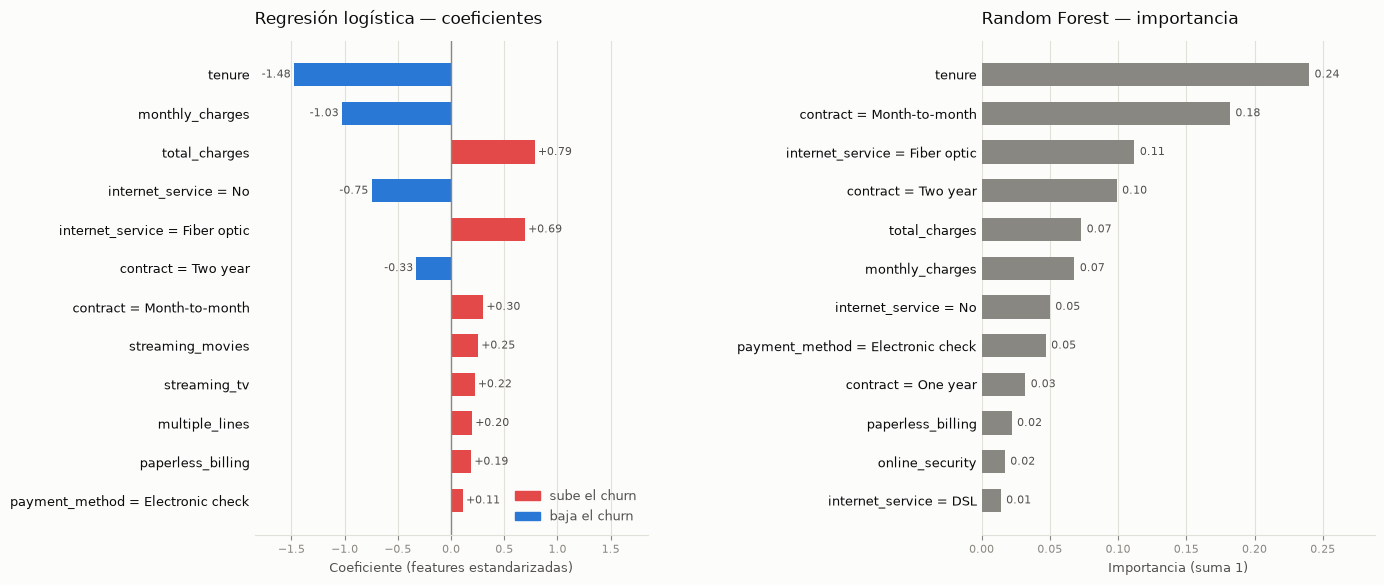

In [43]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Paleta: rojo = sube el churn, azul = lo baja; tinta y ejes en grises neutros
RED, BLUE, GREY = "#e34948", "#2a78d6", "#898781"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e1e0d9"
TOP_N = 12


def short_name(name):
    """contract_ohe_Month-to-month → contract = Month-to-month"""
    return name.replace("_ohe_", " = ")


def style_axis(ax, title, xlabel):
    ax.set_title(title, loc="left", fontsize=12, color=INK, pad=12)
    ax.set_xlabel(xlabel, fontsize=9, color=INK_2)
    ax.tick_params(axis="y", length=0, labelsize=9, colors=INK)
    ax.tick_params(axis="x", labelsize=8, colors=GREY)
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)


fig, (ax_lr, ax_rf) = plt.subplots(1, 2, figsize=(14, 6.5))
fig.subplots_adjust(left=0.17, right=0.97, bottom=0.12, wspace=0.85)

# --- Regresión logística: coeficientes (con signo) -------------------------
top_lr = (
    lr_coefs
    .reindex(lr_coefs["coef"].abs().sort_values(ascending=False).index)
    .head(TOP_N)
    .iloc[::-1]                               # la mayor arriba
)
colors = [RED if c > 0 else BLUE for c in top_lr["coef"]]
ax_lr.barh(top_lr["feature"].map(short_name), top_lr["coef"], color=colors, height=0.6)
ax_lr.axvline(0, color=GREY, linewidth=1)

for y, c in enumerate(top_lr["coef"]):
    ax_lr.text(c + (0.03 if c > 0 else -0.03), y, f"{c:+.2f}",
               va="center", ha="left" if c > 0 else "right", fontsize=8, color=INK_2)

lim = top_lr["coef"].abs().max() * 1.25
ax_lr.set_xlim(-lim, lim)
style_axis(ax_lr, "Regresión logística — coeficientes", "Coeficiente (features estandarizadas)")
ax_lr.legend(
    handles=[Patch(color=RED, label="sube el churn"), Patch(color=BLUE, label="baja el churn")],
    loc="lower right", frameon=False, fontsize=9, labelcolor=INK_2,
)

# --- Random Forest: importancias (sin signo) -------------------------------
top_rf = rf_importances.sort_values("importance", ascending=False).head(TOP_N).iloc[::-1]
ax_rf.barh(top_rf["feature"].map(short_name), top_rf["importance"], color=GREY, height=0.6)

for y, v in enumerate(top_rf["importance"]):
    ax_rf.text(v + 0.004, y, f"{v:.2f}", va="center", fontsize=8, color=INK_2)

ax_rf.set_xlim(0, top_rf["importance"].max() * 1.2)
style_axis(ax_rf, "Random Forest — importancia", "Importancia (suma 1)")

fig.patch.set_facecolor("#fcfcfb")
for ax in (ax_lr, ax_rf):
    ax.set_facecolor("#fcfcfb")

plt.show()

<div style="background-color: #162B36; color: #E6EDF3; padding: 20px; border-radius: 12px; border-left: 5px solid #38BDF8;">

### 📝 Observaciones — Interpretabilidad

Se analizan los coeficientes de la regresión logística (con features estandarizadas, por lo que son comparables entre sí) y la importancia de las features en el Random Forest.   
El árbol de decisión no se incluye: sus reglas son poco legibles con 26 features y no aportan información adicional a la de los otros dos modelos.

#### Factores principales

Ambos modelos coinciden en los factores más relevantes, que además son los detectados en la exploración:

| Factor | Regresión logística | Random Forest | Exploración |
|---|---|---|---|
| tenure | Mayor coeficiente; reduce el churn | 1.ª feature más importante | 47,7 % de churn en el primer año |
| Tipo de contrato | Month-to-month lo aumenta; Two year lo reduce | 2.ª y 4.ª | 42,7 % frente a 2,9 % |
| Fibra óptica | Lo aumenta | 3.ª | 41,9 % |
| Electronic check | Lo aumenta ligeramente | 8.ª | 45,3 % |

La coincidencia entre dos modelos de naturaleza distinta y el análisis descriptivo refuerza que se trata de factores reales y no de un artefacto de un modelo concreto.

#### Multicolinealidad

**monthly_charges** tiene un coeficiente negativo, aunque en la exploración los clientes que abandonan pagan una cuota mayor (74 € frente a 61 €). Se debe a la **multicolinealidad**: total_charges es aproximadamente tenure × monthly_charges, y monthly_charges está muy ligada al servicio de fibra óptica. La regresión logística reparte el efecto entre estas variables de forma válida para predecir, pero sus coeficientes **no deben interpretarse por separado**.

Como mejora futura, se podría evaluar un modelo sin total_charges, variable redundante, para comprobar si mantiene el rendimiento con coeficientes más interpretables.

</div>

## 12. Predicciones y resultados

El resultado final responde a la pregunta de negocio: una **lista de clientes ordenada por probabilidad de churn**, con la decisión basada en el umbral de 0,4 elegido en la sección 10.

Las predicciones se generan sobre el **conjunto de test**, para no puntuar a clientes que el modelo ya ha visto durante el entrenamiento. En un caso real se aplicarían sobre los clientes actuales.

Se guardan dos salidas en **output/**:

- **predictions/** (Parquet): customer_id, contract, tenure, monthly_charges, churn_probability, prediction y label.
- **model_metrics.json**: modelo seleccionado, umbral, tamaño del test y métricas y tiempo de entrenamiento de cada modelo.

In [44]:
from pyspark.ml.functions import vector_to_array

BEST_MODEL_NAME = "logistic_regression"
THRESHOLD = 0.4          # umbral elegido en la sección 10 (no el 0,5 por defecto)

final_predictions = (
    predictions_by_model[BEST_MODEL_NAME]
    .withColumn("churn_probability", vector_to_array(F.col("probability"))[1])
    .withColumn("prediction", (F.col("churn_probability") >= THRESHOLD).cast("double"))
    .withColumn("churn_probability", F.round("churn_probability", 4))
    .select(
        "customer_id",
        "contract",
        "tenure",
        "monthly_charges",
        "churn_probability",
        "prediction",
        "label",
    )
    .orderBy(F.desc("churn_probability"))
)

final_predictions.show(20, truncate=False)

+-----------+--------------+------+---------------+-----------------+----------+-----+
|customer_id|contract      |tenure|monthly_charges|churn_probability|prediction|label|
+-----------+--------------+------+---------------+-----------------+----------+-----+
|9497-QCMMS |Month-to-month|1     |93.55          |0.8407           |1.0       |1.0  |
|9300-AGZNL |Month-to-month|1     |94.0           |0.8387           |1.0       |1.0  |
|1374-DMZUI |Month-to-month|4     |94.3           |0.832            |1.0       |1.0  |
|5150-ITWWB |Month-to-month|3     |94.85          |0.8296           |1.0       |0.0  |
|1069-XAIEM |Month-to-month|1     |85.05          |0.8209           |1.0       |1.0  |
|0295-PPHDO |Month-to-month|1     |95.45          |0.8064           |1.0       |1.0  |
|6630-UJZMY |Month-to-month|4     |83.25          |0.8064           |1.0       |0.0  |
|5277-ZLOOR |Month-to-month|2     |85.55          |0.8048           |1.0       |1.0  |
|1273-MTETI |Month-to-month|4     |88.85   

In [45]:
# Guardamos las prediciones 

predictions_path = OUTPUT_DIR / "predictions"

final_predictions.write.mode("overwrite").parquet(str(predictions_path))

print(f"✅ Predicciones guardadas en {predictions_path}")

✅ Predicciones guardadas en /Users/gloriadelriomarquez/Documents/Career/spark-lab/projects/07-churn-telco-prediction/output/predictions


In [46]:
# Guardamos métricas y tiempos 

results = {
    "selected_model": BEST_MODEL_NAME,
    "decision_threshold": THRESHOLD,
    "test_size": test_df.count(),
    "models": {
        name: {
            **{k: round(v, 4) for k, v in metrics_by_model[name].items()},
            "training_time_s": round(training_times[name], 2),
        }
        for name in metrics_by_model
    },
}

metrics_path = OUTPUT_DIR / "model_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"✅ Métricas guardadas en {metrics_path}")

✅ Métricas guardadas en /Users/gloriadelriomarquez/Documents/Career/spark-lab/projects/07-churn-telco-prediction/output/model_metrics.json


<div style="background-color: #162B36; color: #E6EDF3; padding: 20px; border-radius: 12px; border-left: 5px solid #38BDF8;">

### 📝 Observaciones — Predicciones

Los 20 clientes con mayor probabilidad de churn (entre 0,78 y 0,84) comparten el perfil identificado en la exploración y en la interpretabilidad: **contrato mensual**, **muy poca antigüedad** (13 meses o menos, la mayoría con 1-4 meses) y **cuotas altas** (75 € o más).

De esos 20 clientes, **17 abandonaron realmente** (85 %). En la franja de mayor riesgo, la precisión del modelo es muy superior a la global (58 % con umbral 0,4), lo que la hace especialmente útil para priorizar acciones de retención.

Las métricas guardadas en model_metrics.json corresponden al umbral por defecto (0,5), tal como se calcularon en la sección 9; el umbral de 0,4 solo se aplica a las predicciones guardadas.

</div>

## 13. Comparación con scikit-learn

Se resuelve el mismo problema con scikit-learn para comparar las dos herramientas: diseño de la API, pipelines, métricas y escalabilidad.

Requiere scikit-learn en el entorno del proyecto (uv add scikit-learn).

Para que la comparación sea justa, se usa **el mismo split**: **train_df** y **test_df** se convierten a pandas con **toPandas()**. Esto solo es posible porque el dataset es pequeño y cabe en la memoria del driver, y ahí está precisamente la diferencia de escalabilidad entre ambas herramientas.

| Spark MLlib | scikit-learn |
|---|---|
| **StringIndexer** + **OneHotEncoder** | **OneHotEncoder(handle_unknown="ignore")** |
| **VectorAssembler** | **ColumnTransformer** |
| **Pipeline** | **Pipeline** |
| **LogisticRegression** (estandariza internamente) | **StandardScaler** + **LogisticRegression** |
| **RandomForestClassifier** | **RandomForestClassifier** |
| **BinaryClassificationEvaluator** | **roc_auc_score**, **average_precision_score** |
| **MulticlassClassificationEvaluator** | **precision_score**, **recall_score**, **f1_score** |

In [47]:
import time
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder as SkOneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.linear_model import LogisticRegression as SkLogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score,
)

# Mismo split que en Spark: se convierten train y test a pandas
feature_cols = FEAT_CATEGORICAL_COLS + FEAT_NUMERIC_COLS

train_pd = train_df.select(*feature_cols, "label").toPandas()
test_pd = test_df.select(*feature_cols, "label").toPandas()

X_train, y_train = train_pd[feature_cols], train_pd["label"]
X_test, y_test = test_pd[feature_cols], test_pd["label"]

# Preprocesado equivalente al de Spark
preprocessor = ColumnTransformer([
    ("cat", SkOneHotEncoder(handle_unknown="ignore"), FEAT_CATEGORICAL_COLS),
    ("num", StandardScaler(), FEAT_NUMERIC_COLS),
])

sk_pipeline = SkPipeline([
    ("prep", preprocessor),
    ("model", SkLogisticRegression(max_iter=1000)),
])

start = time.perf_counter()
sk_pipeline.fit(X_train, y_train)
sk_time = time.perf_counter() - start

# Mismas métricas, con umbral 0,5 para comparar con la sección 9
proba = sk_pipeline.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

sk_metrics = {
    "auc_roc": roc_auc_score(y_test, proba),
    "auc_pr": average_precision_score(y_test, proba),
    "accuracy": accuracy_score(y_test, pred),
    "precision_churn": precision_score(y_test, pred),
    "recall_churn": recall_score(y_test, pred),
    "f1_churn": f1_score(y_test, pred),
}

comparison = pd.DataFrame({
    "Spark MLlib": {**metrics_by_model["logistic_regression"], "training_time_s": training_times["logistic_regression"]},
    "scikit-learn": {**sk_metrics, "training_time_s": sk_time},
}).round(4)

comparison

,Spark MLlib,scikit-learn
auc_roc,0.8607,0.8606
auc_pr,0.6635,0.6662
accuracy,0.8154,0.8146
precision_churn,0.6334,0.6323
recall_churn,0.6006,0.5976
f1_churn,0.6166,0.6144
training_time_s,7.1103,0.0993


<div style="background-color: #162B36; color: #E6EDF3; padding: 20px; border-radius: 12px; border-left: 5px solid #38BDF8;">

### 📝 Observaciones — scikit-learn vs Spark MLlib

Se entrenó la misma regresión logística con scikit-learn, usando el mismo split (train y test convertidos a pandas) y un preprocesado equivalente (OneHotEncoder + StandardScaler).

| Métrica | Spark MLlib | scikit-learn |
|---|---:|---:|
| AUC-ROC | 0,861 | 0,861 |
| AUC-PR | 0,664 | 0,666 |
| Accuracy | 0,815 | 0,815 |
| Precision (churn) | 0,633 | 0,632 |
| Recall (churn) | 0,601 | 0,598 |
| F1 (churn) | 0,617 | 0,614 |
| **Tiempo de entrenamiento** | **7,11 s** | **0,10 s** |

**Métricas equivalentes:** las diferencias son inferiores a 0,003 en todas las métricas. Ambas librerías implementan el mismo algoritmo, y la coincidencia confirma que el pipeline de Spark es correcto. Las pequeñas variaciones se deben a detalles de implementación (scikit-learn aplica regularización por defecto; la AUC-PR se calcula con métodos ligeramente distintos).

**Tiempo de entrenamiento:** scikit-learn es unas 70 veces más rápido. Con 5.705 filas de entrenamiento, el coste fijo de coordinación de Spark (planificación de tareas, serialización, comunicación entre procesos) domina el tiempo total. El tiempo de Spark incluye además el calentamiento de la primera ejecución. La magnitud exacta varía entre ejecuciones (en otra ejecución: 5,3 s frente a 0,3 s), pero la diferencia es siempre de más de un orden de magnitud.

**Conclusión:** para datos que caben en la memoria de una sola máquina, scikit-learn es la opción más eficiente. Spark MLlib aporta valor cuando el volumen de datos supera la capacidad de una máquina o cuando los datos ya residen en un entorno distribuido. Este proyecto usa Spark con fines de aprendizaje: la conversión con toPandas() solo es posible porque el dataset es pequeño.

</div>

<div style="background-color: #162B36; color: #E6EDF3; padding: 22px; border-radius: 12px; border-left: 5px solid #38BDF8;">

## 14. Conclusiones generales

Se ha construido un pipeline de clasificación con Spark MLlib que estima la probabilidad de abandono de clientes de telecomunicaciones. El modelo final (**regresión logística**) alcanza una **AUC-ROC de 0,86** y, con un umbral de decisión de 0,4, detecta el **72 % de los clientes que abandonan**.

---

### 🧹 Calidad de los datos

El dataset estaba en buen estado, pero requirió varias decisiones de limpieza documentadas:

- **total_charges** se infirió como texto por 11 valores en blanco. Correspondían a clientes con tenure = 0, cuya etiqueta no es fiable (no han tenido tiempo de abandonar), por lo que se eliminaron.
- Las categorías **No internet service** y **No phone service** repetían en siete columnas información ya recogida en internet_service y phone_service. Se recodificaron como **No**, convirtiendo esas columnas en binarias sin pérdida de información.
- No había registros duplicados; los 42 clientes con perfil idéntico son coincidencias legítimas.

---

### 🔎 Factores asociados al churn

La exploración, la regresión logística y el Random Forest coinciden en los mismos factores principales:

| Factor | Efecto sobre el churn |
|---|---|
| **Antigüedad (tenure)** | El factor más relevante: 47,7 % de churn en el primer año frente al 9,5 % con más de 48 meses |
| **Tipo de contrato** | Month-to-month: 42,7 % · Two year: 2,9 % |
| **Fibra óptica** | 41,9 % frente al 19,0 % con DSL |
| **Electronic check** | 45,3 % frente al 15-19 % del resto de métodos de pago |

Que tres enfoques distintos coincidan refuerza que se trata de patrones reales de los datos. Son asociaciones, no relaciones causales.

---

### 🤖 Modelos

| Modelo | AUC-ROC | AUC-PR | F1 (churn) |
|---|---:|---:|---:|
| **Regresión logística** | **0,861** | **0,664** | **0,617** |
| Random Forest | 0,851 | 0,658 | 0,547 |
| Árbol de decisión | 0,822 | 0,638 | 0,605 |

La **regresión logística** obtiene el mejor resultado. El churn depende de pocos factores con una relación bastante directa, que un modelo lineal captura bien: un modelo más complejo no aporta mejora cuando no hay patrones que el modelo simple no pueda captar.

---

### 🎚️ Umbral de decisión

Con el umbral por defecto (0,5), el modelo detecta el 60 % de los churners. Bajarlo aumenta la detección con **rendimiento decreciente**: cada churner adicional cuesta 1,5 falsas alarmas al pasar a 0,4, y 5,5 al pasar de 0,3 a 0,2.

Se elige **0,4** como umbral equilibrado (mejor F1, recall del 72 %). La elección final depende del negocio: si una acción de retención es barata en comparación con perder un cliente, un umbral de 0,3 detecta el 82 % de los churners.

---

### ⚖️ Spark MLlib frente a scikit-learn

La misma regresión logística en scikit-learn obtiene métricas equivalentes (diferencias < 0,003) y entrena **más de un orden de magnitud más rápido** (0,1 s frente a 7,1 s). Con datos que caben en memoria, el coste de coordinación de Spark no compensa. Spark MLlib aporta valor cuando el volumen de datos supera la capacidad de una máquina o los datos ya residen en un entorno distribuido.

---

### ⚠️ Limitaciones

- El **umbral** se eligió sobre el conjunto de test; lo correcto sería elegirlo con datos de validación.
- **Multicolinealidad:** total_charges ≈ tenure × monthly_charges. Los coeficientes de estas variables no deben interpretarse por separado.
- Los modelos se entrenaron con **hiperparámetros fijos**, sin ajuste.
- El dataset es una **foto de un momento concreto** (churn en el último mes); no captura la evolución del comportamiento del cliente en el tiempo.

---

### 🚀 Próximos pasos

- Ajustar hiperparámetros con **CrossValidator** y elegir el umbral con validación cruzada.
- Evaluar un modelo **sin total_charges** para reducir la redundancia.
- Probar **ponderación de clases** (weightCol) como alternativa al ajuste del umbral.
- Traducir el umbral a un criterio de **coste de negocio** (coste de retención frente a valor del cliente).

---

### 🎯 Idea principal

Un buen modelo de churn no es solo una métrica alta. Requiere **datos limpios con decisiones justificadas**, un **modelo interpretable** que confirme lo observado en la exploración y un **umbral elegido según el coste de cada error**. El modelo más sencillo fue el mejor: la complejidad solo se justifica cuando mejora el resultado.

</div>